In [103]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [104]:
#read csv data
customer_data=pd.read_csv("customer cancellation copy - Sheet1.csv")

In [105]:
customer_data.head(5)

,Customer ID,Gender,Age,Married,Number of Dependents,City,Number of Referrals,Tenure in Months,Offer,Phone Service,Avg Monthly Long Distance Charges,Multiple Lines,Internet Service,Internet Type,Avg Monthly GB Download,Online Security,Online Backup,Device Protection Plan,Premium Tech Support,Streaming TV,Streaming Movies,Streaming Music,Unlimited Data,Contract,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Average Monthly Revenue,Customer Status,Churn Category,Churn Reason,Churned,Stayed,Most Common Churn Reason,2nd Most Common Charn Reason,3rd Most Common Charn Reason
0,0021-IKXGC,Female,72,No,0,San Marcos,0,1,Offer E,Yes,7.77,Yes,Yes,Fiber Optic,22.0,No,No,No,No,No,No,No,Yes,One Year,Bank Withdrawal,72.10,72.10,0.0,0,7.77,79.87,79.87,Joined,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0023-HGHWL,Male,67,No,0,Morgan Hill,0,1,NaN,No,NaN,NaN,Yes,Cable,9.0,No,No,No,No,No,No,No,Yes,Month-to-Month,Bank Withdrawal,25.10,25.10,0.0,0,0.00,25.10,25.10,Churned,Competitor,Competitor made better offer,25.10,NaN,NaN,25.1,NaN
2,0032-PGELS,Female,37,Yes,1,Palomar Mountain,1,1,NaN,No,NaN,NaN,Yes,DSL,19.0,Yes,No,No,No,No,No,No,Yes,Month-to-Month,Bank Withdrawal,30.50,30.50,0.0,0,0.00,30.50,30.50,Churned,Attitude,Attitude of service provider,30.50,NaN,NaN,NaN,NaN
3,0082-LDZUE,Male,54,No,0,Calistoga,0,1,Offer E,Yes,42.95,No,Yes,DSL,9.0,No,No,No,No,No,No,No,Yes,Month-to-Month,Credit Card,44.30,44.30,0.0,0,42.95,87.25,87.25,Joined,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0107-WESLM,Male,32,No,0,West Point,0,1,Offer E,Yes,31.77,No,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Month-to-Month,Bank Withdrawal,19.85,19.85,0.0,0,31.77,51.62,51.62,Churned,Attitude,Attitude of support person,51.62,NaN,NaN,NaN,51.62


In [106]:
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 40 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Married                            7043 non-null   object 
 4   Number of Dependents               7043 non-null   int64  
 5   City                               7043 non-null   object 
 6   Number of Referrals                7043 non-null   int64  
 7   Tenure in Months                   7043 non-null   int64  
 8   Offer                              3166 non-null   object 
 9   Phone Service                      7043 non-null   object 
 10  Avg Monthly Long Distance Charges  6361 non-null   float64
 11  Multiple Lines                     6361 non-null   objec

In [107]:
#Overall churn rate
#propotion of churned customers
total_customers = len(customer_data)

churned_customers = (
    customer_data["Customer Status"] == "Churned"
).sum()

churn_rate = churned_customers / total_customers * 100

print("Total customers:", total_customers)
print("Churned customers:", churned_customers)
print(f"Churn rate: {churn_rate:.2f}%")

Total customers: 7043
Churned customers: 1869
Churn rate: 26.54%


In [109]:
#Churn by Customer Characteristics
#Calculate churn rate by tenure
tenure_churn_rate = (
    customer_data.groupby("Tenure in Months")["Customer Status"]
    .apply(lambda x: (x == "Churned").mean() * 100)
)

print(tenure_churn_rate)

Tenure in Months
1     61.990212
2     51.680672
3     47.000000
4     47.159091
5     48.120301
        ...    
68     9.000000
69     8.421053
70     9.243697
71     3.529412
72     1.657459
Name: Customer Status, Length: 72, dtype: float64


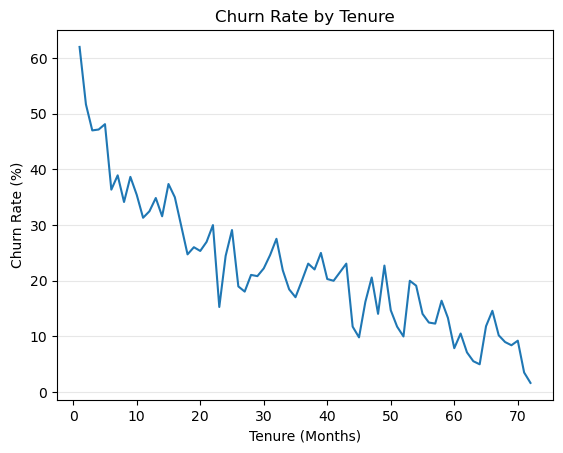

In [110]:
#plot tenure_churn rate
plt.plot(
    tenure_churn_rate.index,
    tenure_churn_rate.values
)

plt.title("Churn Rate by Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Churn Rate (%)")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [111]:
#Calculate churn rate by Age
#create age groups
customer_data["Age Group"]=pd.cut(
    customer_data["Age"],
    bins=[0,25,35,45,55,65,100],
    labels=["18-25",
        "26-35",
        "36-45",
        "46-55",
        "56-65",
        "66+"])

In [112]:
#calculate age group churnrate
age_group_churn = (
    customer_data.groupby("Age Group", observed=True)["Customer Status"]
    .apply(lambda x: (x == "Churned").mean() * 100)
)

print(age_group_churn)

Age Group
18-25    20.719738
26-35    24.121406
36-45    23.561013
46-55    25.351014
56-65    24.469821
66+      41.862653
Name: Customer Status, dtype: float64


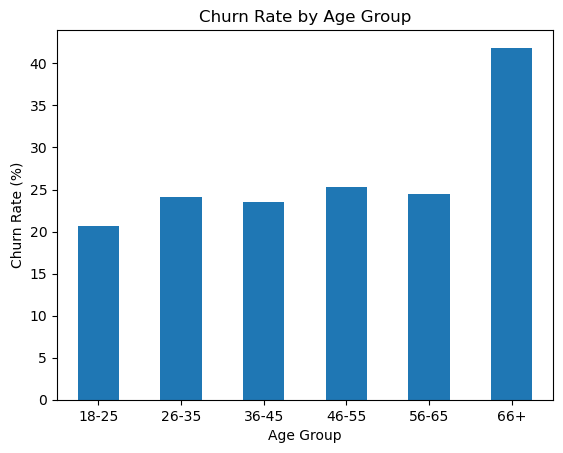

In [113]:
#plot the bar plot for age_group_churn
age_group_churn.plot(kind="bar")

plt.title("Churn Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

In [114]:
# create a single summary DataFrame showing churn rate by characteristics
#sort value from highest to lowest churn rate by characteristics
characteristics=["Internet Service",
                    "Internet Type",
                    "Multiple Lines",
                    "Offer",
                    "Contract",
                    "Online Security",
                    "Online Backup",
                    "Device Protection Plan",
                    "Premium Tech Support",
                    "Streaming TV",
                    "Streaming Movies",
                    "Streaming Music",
                    "Unlimited Data",
                    "Payment Method",
                    "Gender"]
#Create an empty list
results=[]
#Loop through each characteristic

for column in characteristics:
    
    churn_rate = (
        customer_data
        .groupby(column)["Customer Status"]
        .apply(lambda x: (x == "Churned").mean() * 100)
    )
    
    for group, rate in churn_rate.items():
        results.append({
            "Characteristic": column,
            "Group": group,
            "Churn Rate (%)": rate
        })

churn_summary = pd.DataFrame(results)

churn_summary = churn_summary.sort_values(
    "Churn Rate (%)",
    ascending=False
)

print(churn_summary)

            Characteristic            Group  Churn Rate (%)
11                   Offer          Offer E       52.919255
12                Contract   Month-to-Month       45.844875
15         Online Security               No       41.766724
21    Premium Tech Support               No       41.635474
4            Internet Type      Fiber Optic       40.724876
17           Online Backup               No       39.928756
19  Device Protection Plan               No       39.127625
33          Payment Method     Mailed Check       36.883117
31          Payment Method  Bank Withdrawal       33.998465
27         Streaming Music               No       33.938594
25        Streaming Movies               No       33.680431
23            Streaming TV               No       33.523132
29          Unlimited Data               No       32.901554
1         Internet Service              Yes       31.828893
30          Unlimited Data              Yes       31.654373
24            Streaming TV              

In [115]:
#from summarry table identify high risk groups
high_risk_groups = [
    ("Offer", "Offer E"),
    ("Online Security", "No"),
    ("Premium Tech Support", "No"),
    ("Internet Type", "Fiber Optic"),
    ("Online Backup", "No"),
    ("Device Protection Plan", "No"),
    ("Payment Method", "Mailed Check"),
    ("Contract","Month-to-Month"),
    ("Tenure in Months",1)
]

In [116]:
#Analyse churn reason among high risk groups
# creating for loop to calculate high-risk_churn_groups churn reason
# Each tuple contains:(column, value)

for column, value in high_risk_groups:

    group_churn = customer_data[
        (customer_data["Customer Status"] == "Churned") &
        (customer_data[column] == value)
    ]

    reasons = group_churn["Churn Reason"].value_counts()

    percentages = (reasons / reasons.sum()) * 100

    summary = pd.DataFrame({
        "Churned Customers": reasons,
        "Percentage": percentages
    })

    print(f"\n{column} = {value}")
    print(summary.head(3))


Offer = Offer E
                               Churned Customers  Percentage
Churn Reason                                                
Competitor made better offer                  78   18.309859
Competitor had better devices                 77   18.075117
Attitude of support person                    54   12.676056

Online Security = No
                               Churned Customers  Percentage
Churn Reason                                                
Competitor had better devices                292   19.986311
Competitor made better offer                 245   16.769336
Attitude of support person                   146    9.993155

Premium Tech Support = No
                               Churned Customers  Percentage
Churn Reason                                                
Competitor had better devices                272   18.810512
Competitor made better offer                 242   16.735823
Attitude of support person                   157   10.857538

Internet Type = Fi

In [117]:
#How much revenue is associated with churn reason? we used average monthly revenue
revenue_by_reason=(
   customer_data
   .groupby("Churn Reason")["Average Monthly Revenue"]
   .mean()
   .sort_values(ascending=False)
    
)
print(revenue_by_reason)

Churn Reason
Competitor offered more data                 103.451368
Extra data charges                           103.380769
Moved                                        103.212174
Lack of affordable download/upload speed     102.858333
Competitor offered higher download speeds    101.715500
Product dissatisfaction                      101.158831
Competitor had better devices                100.951885
Competitor made better offer                 100.813666
Price too high                                99.695513
Network reliability                           98.078611
Don't know                                    97.356846
Attitude of service provider                  97.169574
Service dissatisfaction                       96.995238
Poor expertise of online support              94.855806
Limited range of services                     93.637027
Attitude of support person                    93.240773
Poor expertise of phone support               92.969167
Lack of self-service on Website    

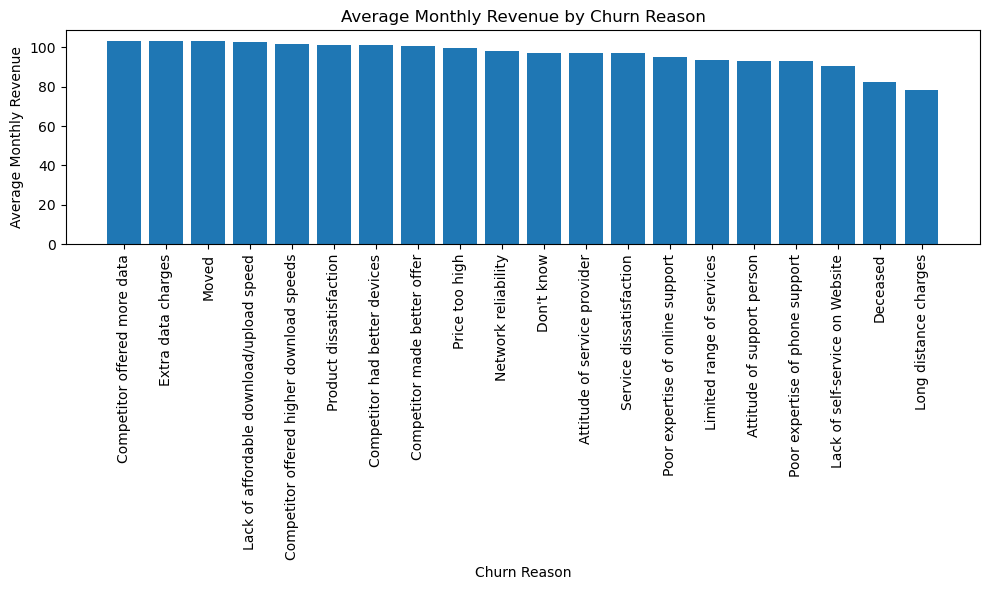

In [118]:
plt.figure(figsize=(10, 6))

plt.bar(
    revenue_by_reason.index,
    revenue_by_reason.values
)

plt.title("Average Monthly Revenue by Churn Reason")
plt.xlabel("Churn Reason")
plt.ylabel("Average Monthly Revenue")

plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

In [119]:
#"Which churn reasons are associated with the most total monthly revenue at risk?"
revenue_at_risk = (
    churned_monthly_revenue
    .groupby("Churn Reason")["Average Monthly Revenue"]
    .sum()
    .sort_values(ascending=False)
)

print(revenue_at_risk)

Churn Reason
Competitor had better devices                31597.854081
Competitor made better offer                 31352.948293
Attitude of support person                   20512.849555
Don't know                                   12656.312537
Competitor offered more data                 12103.778509
Competitor offered higher download speeds    10171.529226
Attitude of service provider                  9133.918384
Product dissatisfaction                       7789.211570
Price too high                                7776.202652
Network reliability                           7061.633074
Service dissatisfaction                       6110.669562
Long distance charges                         5012.437291
Moved                                         4747.762016
Extra data charges                            4031.844665
Limited range of services                     3464.518704
Lack of affordable download/upload speed      3085.742186
Poor expertise of online support              2940.530827
L

In [120]:
#one summary DataFrame showing total monthly revenue and average monthly revenue
revenue_summary = (
    churned_monthly_revenue
    .groupby("Churn Reason")
    .agg(
        Churned_Customers=("Churn Reason", "size"),
        Average_Monthly_Revenue=("Average Monthly Revenue", "mean"),
        Total_Monthly_Revenue=("Average Monthly Revenue", "sum")
    )
    .sort_values("Total_Monthly_Revenue", ascending=False)
)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

print(revenue_summary)


                                           Churned_Customers  Average_Monthly_Revenue  Total_Monthly_Revenue
Churn Reason                                                                                                
Competitor had better devices                            313               100.951610           31597.854081
Competitor made better offer                             311               100.813339           31352.948293
Attitude of support person                               220                93.240225           20512.849555
Don't know                                               130                97.356250           12656.312537
Competitor offered more data                             117               103.451098           12103.778509
Competitor offered higher download speeds                100               101.715292           10171.529226
Attitude of service provider                              94                97.169345            9133.918384
Product dissatisfac

In [121]:
#Create a overall summary for each high-risk group
high_risk_groups=[
    ("Offer", "Offer E"),
    ("Online Security", "No"),
    ("Premium Tech Support", "No"),
    ("Internet Type", "Fiber Optic"),
    ("Online Backup", "No"),
    ("Device Protection Plan", "No"),
    ("Payment Method", "Mailed Check"),
    ("Contract","Month-to-Month"),
    ("Tenure in Months",1),
    ("Age Group","66+"),
    
]
#Now we'll create a summary DataFrame.
results = []

for column, value in high_risk_groups:

    # All customers in this group
    group = customer_data[
        customer_data[column] == value
    ]

    # Churned customers in this group
    churned_group = group[
        group["Customer Status"] == "Churned"
    ]

    # Calculate churn rate
    churn_rate = len(churned_group) / len(group) * 100

    # Calculate revenue associated with churn
    total_revenue = churned_group["Total Revenue"].sum()

    results.append({
        "Characteristic": column,
        "Group": value,
        "Customers": len(group),
        "Churned Customers": len(churned_group),
        "Churn Rate (%)": churn_rate,
        "Total Revenue from Churned Customers": total_revenue
    })

high_risk_summary = pd.DataFrame(results)

print(high_risk_summary)

           Characteristic           Group  Customers  Churned Customers  Churn Rate (%)  Total Revenue from Churned Customers
0                   Offer         Offer E        805                426       52.919255                             120751.68
1         Online Security              No       3498               1461       41.766724                            2661022.68
2    Premium Tech Support              No       3473               1446       41.635474                            2603628.39
3           Internet Type     Fiber Optic       3035               1236       40.724876                            3021108.08
4           Online Backup              No       3088               1233       39.928756                            1820753.43
5  Device Protection Plan              No       3095               1211       39.127625                            1792176.49
6          Payment Method    Mailed Check        385                142       36.883117                              9

In [122]:
#investigate combinations of characteristics
#Tenure Group column that puts customers into broader categories.
customer_data["Tenure Group"]=pd.cut(
    customer_data["Tenure in Months"],
    bins=[0, 6, 12, 24, 48, float("inf")],
    labels=["0-6 months", "7-12 months", "13-24 months", "25-48 months", "49+ months"]
)

In [123]:
print(customer_data[["Tenure in Months", "Tenure Group"]].head(20))

    Tenure in Months Tenure Group
0                  1   0-6 months
1                  1   0-6 months
2                  1   0-6 months
3                  1   0-6 months
4                  1   0-6 months
5                  1   0-6 months
6                  1   0-6 months
7                  1   0-6 months
8                  1   0-6 months
9                  1   0-6 months
10                 1   0-6 months
11                 1   0-6 months
12                 1   0-6 months
13                 1   0-6 months
14                 1   0-6 months
15                 1   0-6 months
16                 1   0-6 months
17                 1   0-6 months
18                 1   0-6 months
19                 1   0-6 months


In [124]:
print(customer_data["Tenure Group"].value_counts().sort_index())

Tenure Group
0-6 months      1470
7-12 months      716
13-24 months    1024
25-48 months    1594
49+ months      2239
Name: count, dtype: int64


In [125]:
#Calculate churn rate by Tenure Group
tenure_churn = (
    customer_data
    .groupby("Tenure Group", observed=True)["Customer Status"]
    .apply(lambda x: (x == "Churned").mean() * 100)
)

print(tenure_churn)

Tenure Group
0-6 months      53.333333
7-12 months     35.335196
13-24 months    28.710938
25-48 months    20.388959
49+ months       9.513176
Name: Customer Status, dtype: float64


In [126]:
#Calculate churn rate by Contract × Tenure Group
contract_tenure_churn = (
    customer_data
    .groupby(["Contract", "Tenure Group"], observed=True)["Customer Status"]
    .apply(lambda x: (x == "Churned").mean() * 100)
)

print(contract_tenure_churn)

Contract        Tenure Group
Month-to-Month  0-6 months      57.059254
                7-12 months     44.688645
                13-24 months    40.524781
                25-48 months    36.923077
                49+ months      30.067568
One Year        0-6 months       7.692308
                7-12 months      9.574468
                13-24 months     7.441860
                25-48 months    10.073260
                49+ months      12.752722
Two Year        0-6 months       0.000000
                7-12 months      0.000000
                13-24 months     0.000000
                25-48 months     1.801802
                49+ months       3.230769
Name: Customer Status, dtype: float64


In [127]:
#Now that we've identified Month-to-Month + short tenure as a high-risk segment, let's cross-reference it with Churn Reason.
high_risk = customer_data[
    (customer_data["Contract"] == "Month-to-Month") &
    (customer_data["Tenure Group"] == "0-6 months") &
    (customer_data["Customer Status"] == "Churned")
]

In [128]:
#Count their churn reasons
high_risk_reasons = (
    high_risk["Churn Reason"]
    .value_counts()
)

print(high_risk_reasons)

Churn Reason
Competitor made better offer                 146
Competitor had better devices                141
Attitude of support person                    82
Don't know                                    54
Attitude of service provider                  48
Competitor offered higher download speeds     37
Long distance charges                         35
Network reliability                           34
Competitor offered more data                  30
Price too high                                30
Service dissatisfaction                       24
Product dissatisfaction                       24
Moved                                         19
Limited range of services                     17
Lack of self-service on Website               14
Poor expertise of online support              13
Lack of affordable download/upload speed      12
Extra data charges                            11
Poor expertise of phone support                6
Deceased                                       3
Name: c

In [129]:
high_risk_reason_pct = (
    high_risk["Churn Reason"]
    .value_counts(normalize=True)
    * 100
)

print(high_risk_reason_pct)

Churn Reason
Competitor made better offer                 18.717949
Competitor had better devices                18.076923
Attitude of support person                   10.512821
Don't know                                    6.923077
Attitude of service provider                  6.153846
Competitor offered higher download speeds     4.743590
Long distance charges                         4.487179
Network reliability                           4.358974
Competitor offered more data                  3.846154
Price too high                                3.846154
Service dissatisfaction                       3.076923
Product dissatisfaction                       3.076923
Moved                                         2.435897
Limited range of services                     2.179487
Lack of self-service on Website               1.794872
Poor expertise of online support              1.666667
Lack of affordable download/upload speed      1.538462
Extra data charges                            1.4102